# Outliers

An outlier is a data point that differs significantly from the other observations in a dataset. Outliers can arise from measurement errors, data entry mistakes, or they may represent genuine but rare events. Either way, they matter — outliers can skew summary statistics like the mean, distort model training, and lead to misleading conclusions.

## How do we detect outliers?

The most common approach is the **IQR (Interquartile Range) method**, which is based on the **5-number summary**:

| Statistic | Description |
|-----------|-------------|
| Minimum   | Smallest value |
| Q1        | 25th percentile — 25% of data falls below this |
| Median    | 50th percentile — the middle value |
| Q3        | 75th percentile — 75% of data falls below this |
| Maximum   | Largest value |

The **IQR** is the range between Q1 and Q3 (`IQR = Q3 - Q1`). Any point that falls below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` is flagged as an outlier.

In this notebook, we apply this method to a list of student grades and use box plots to visualize both clean data and data with outliers introduced.

In [1]:
import numpy as np
lst_grades = [88, 92, 79, 93, 85, 90, 91, 87, 94, 89, 95, 90, 91, 88, 92, 89, 94, 90, 91, 93]
minimum, Q1, median, Q3, maximum = np.percentile(lst_grades, [0, 25, 50, 75, 100])

In [2]:
minimum, Q1, median, Q3, maximum

(np.float64(79.0),
 np.float64(88.75),
 np.float64(90.5),
 np.float64(92.25),
 np.float64(95.0))

In [3]:
IQR = Q3 - Q1
print(f'IQR: {IQR}')

IQR: 3.5


In [4]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Lower Bound: {lower_bound}')
print(f'Upper Bound: {upper_bound}')

Lower Bound: 83.5
Upper Bound: 97.5


In [5]:
import seaborn as sns

<Axes: >

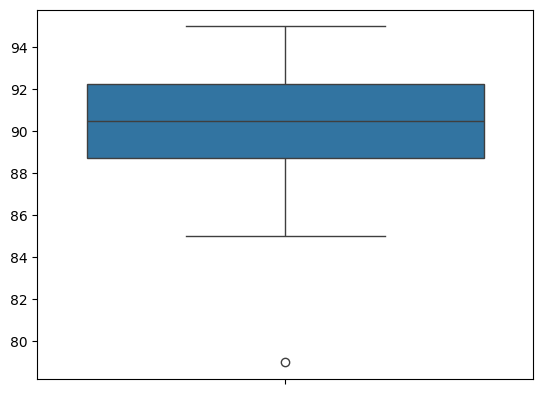

In [7]:
sns.boxplot(lst_grades)

In [8]:
lst_grades = [88, 92, 79, 93, 85, 90, 14, 21, 6, 91, 87, 94, 89, 95, 90, 91, 88, 92, 89, 94, 90, 91, 93]


<Axes: >

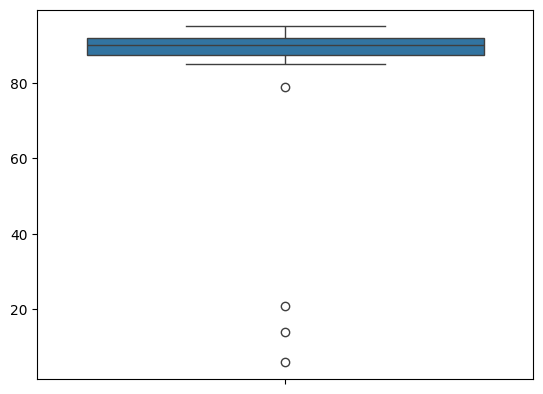

In [9]:
sns.boxplot(lst_grades)

## Conclusion

In this notebook, we used a list of student grades to explore outlier detection with the IQR method and box plots.

On the **clean dataset**, the 5-number summary gave us Q1 = 88.75, median = 90.5, Q3 = 92.25, and an IQR of 3.5. Applying the 1.5 × IQR rule set the lower bound at 83.5 and the upper bound at 97.5 — meaning any grade outside that range would be flagged as an outlier. The first box plot confirmed the data was tight and well-behaved with no outliers.

When we **introduced outliers** (grades of 6, 14, and 21), the second box plot immediately showed them as isolated points far below the whisker, making them easy to spot visually.

**Key takeaways:**
- The IQR method is robust because it is based on percentiles, not the mean — so existing outliers don't influence the bounds used to detect them.
- Box plots are one of the fastest ways to visually identify outliers and understand the spread of your data.
- Once outliers are identified, you have options: remove them (if they're errors), cap them (winsorization), or investigate them further — the right choice depends on the context.